In [1]:
import geopandas as gpd
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'notebook'


# Load the GeoPackage
fastfood = gpd.read_file("fastfood_all_ohio.gpkg", layer="fastfood")

In [2]:
# Count occurrences of each chain
counts = fastfood["name"].value_counts()

# Optional: convert to a DataFrame for nicer display
counts_df = counts.reset_index()
counts_df.columns = ["fastfood_chain", "count"]

print(counts_df)

            fastfood_chain  count
0               McDonald's    615
1                   Subway    584
2                  Wendy's    368
3                Taco Bell    324
4              Burger King    281
..                     ...    ...
940        Popcorn Pizzazz      1
941           Pretzel Fest      1
942             Nori Japan      1
943  Fruit for all Seasons      1
944          Phantom Pizza      1

[945 rows x 2 columns]


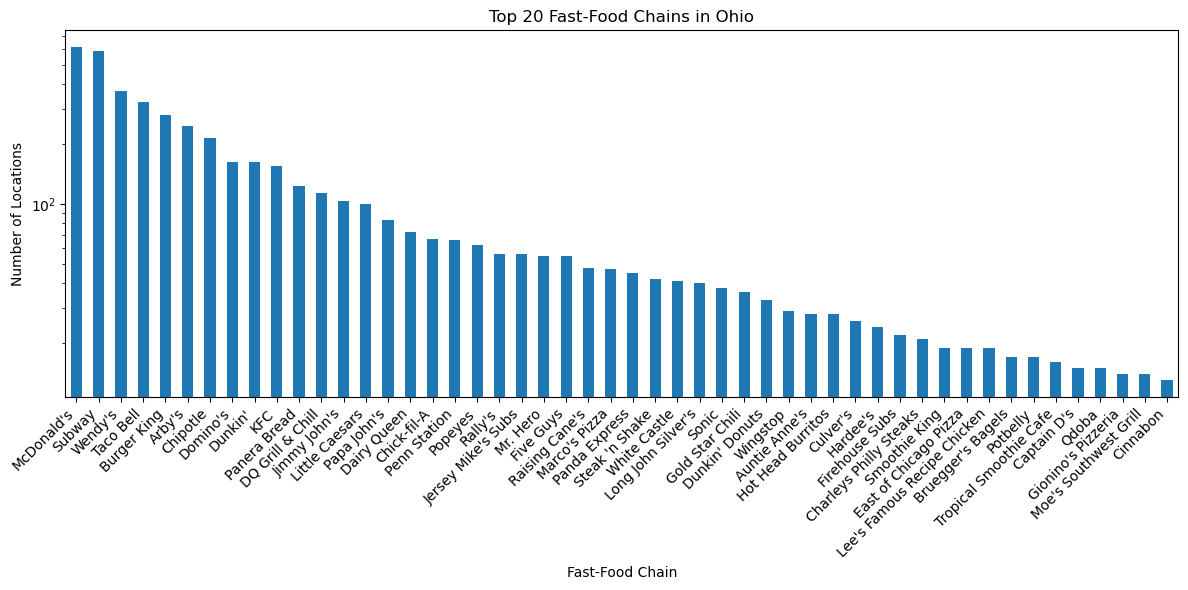

In [7]:
counts = fastfood["name"].value_counts().head(50)  
import matplotlib.pyplot as plt
# Plot
plt.figure(figsize=(12, 6))
counts.plot(kind="bar")
plt.title("Top 20 Fast-Food Chains in Ohio")
plt.ylabel("Number of Locations")
plt.xlabel("Fast-Food Chain")
plt.yscale("log")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

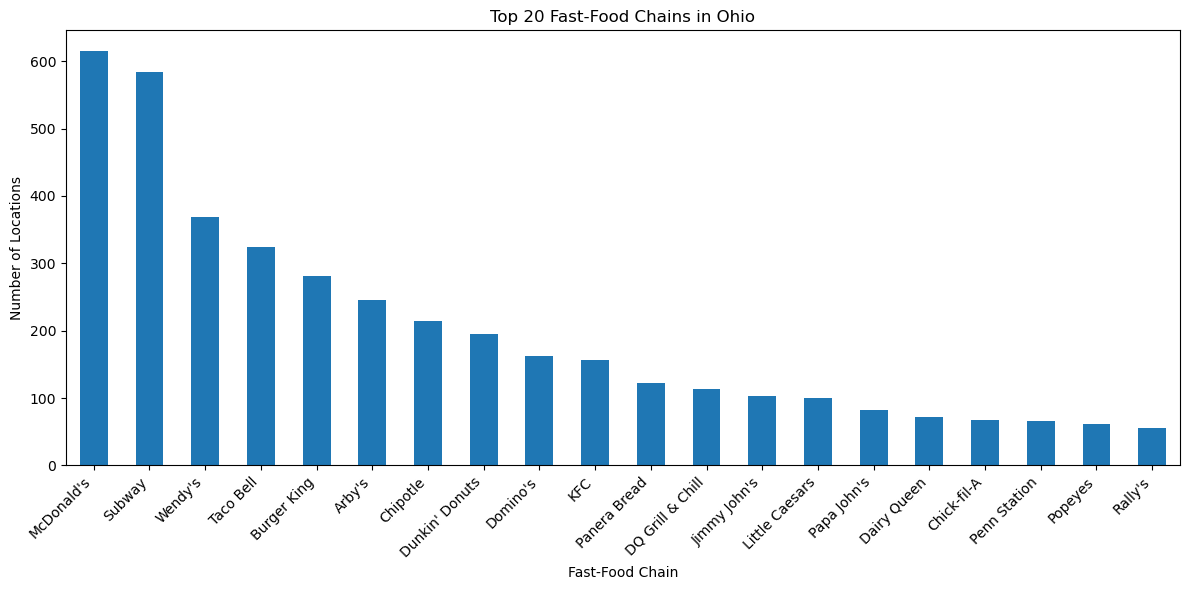

In [10]:
#dunkin' and dunkin' donuts is the same (recent rebranding)
fastfood["name_normalized"] = fastfood["name"].replace({
    "Dunkin'": "Dunkin' Donuts",
    "Dunkin": "Dunkin' Donuts"
})

counts = fastfood["name_normalized"].value_counts().head(20)

plt.figure(figsize=(12, 6))
counts.plot(kind="bar")
plt.title("Top 20 Fast-Food Chains in Ohio")
plt.ylabel("Number of Locations")
plt.xlabel("Fast-Food Chain")
#plt.yscale("log")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

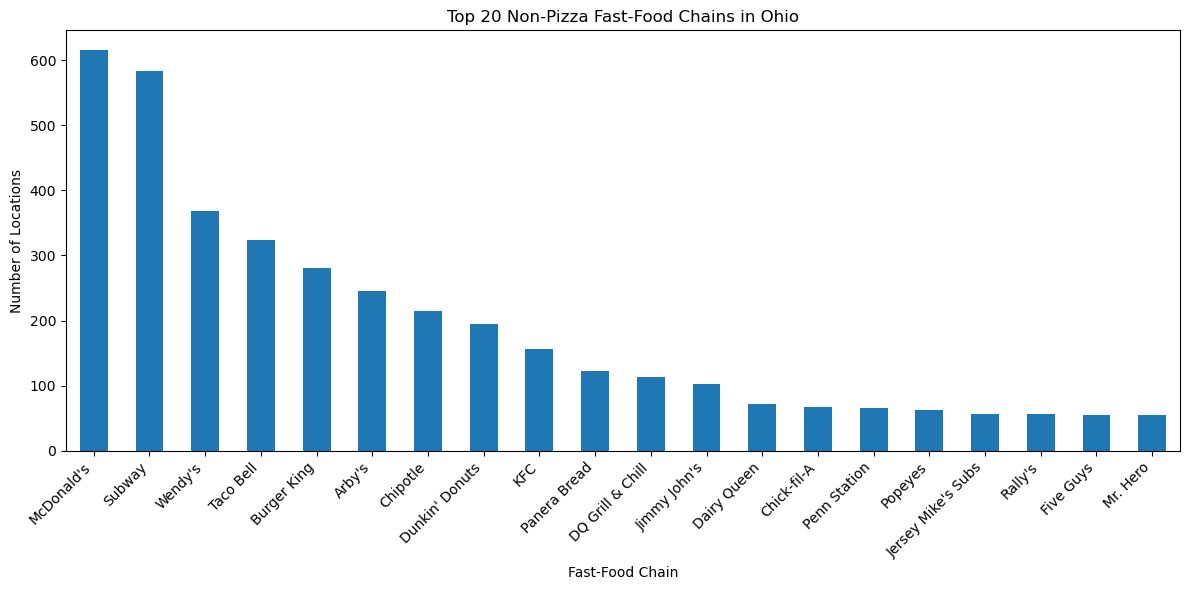

In [14]:
# List of pizza chains to exclude
pizza_chains = [
    "Domino's", "Papa John's", "Little Caesars", 
    "Marco's Pizza", "Donatos Pizza", "Imo's Pizza", "Mancino's", "Donatos"
]

# Filter out pizza chains
fastfood_non_pizza = fastfood[~fastfood["name_normalized"].isin(pizza_chains)]

# Count occurrences of each remaining chain
counts = fastfood_non_pizza["name_normalized"].value_counts().head(20)

# Plot
plt.figure(figsize=(12, 6))
counts.plot(kind="bar")
plt.title("Top 20 Non-Pizza Fast-Food Chains in Ohio")
plt.ylabel("Number of Locations")
plt.xlabel("Fast-Food Chain")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

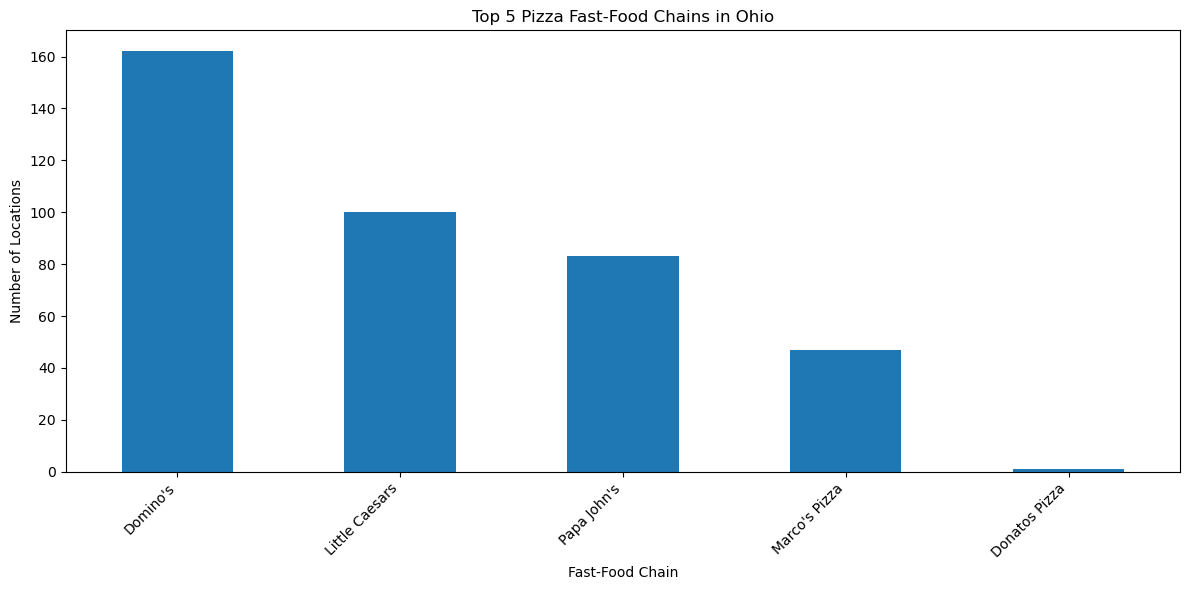

In [16]:
# Filter out pizza chains
fastfood_pizza = fastfood[fastfood["name_normalized"].isin(pizza_chains)]

# Count occurrences of each remaining chain
counts = fastfood_pizza["name_normalized"].value_counts().head(5)

# Plot
plt.figure(figsize=(12, 6))
counts.plot(kind="bar")
plt.title("Top 5 Pizza Fast-Food Chains in Ohio")
plt.ylabel("Number of Locations")
plt.xlabel("Fast-Food Chain")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()